# Predicting Public Transport Delays Using Weather and City Events

## Project Overview

This project explores whether public transport delays can be predicted using schedule information, weather conditions, traffic congestion, and city-event context.

The dataset contains trip-level transport records with route and stop information, scheduled timings, weather indicators, traffic conditions, and event-related attributes. The project investigates two machine learning formulations:

1. **Regression** — predict the exact arrival delay in minutes  
2. **Classification** — predict whether a trip will be delayed or not

The final project emphasizes **classification as the main task** and keeps **regression as a secondary analysis**. This decision was made after comparing both formulations and evaluating their results against simple baselines.

## Project Goals

- inspect and clean the dataset
- engineer useful time, weather, traffic, and event features
- avoid data leakage by removing target-related columns from model inputs
- build regression and classification models
- compare each model against proper dummy baselines
- evaluate performance honestly
- document the strengths and limitations of the dataset

---

## Dataset

**File used:** `public_transport_delays.csv`

Targets used in this project:
- `actual_arrival_delay_min` for regression
- `delayed` for classification

---

## Imports



In [1]:
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)



## Loading the Data



In [2]:
df = pd.read_csv("public_transport_delays.csv")
print("Shape:", df.shape)
df.head()


Shape: (2000, 24)


,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,actual_arrival_delay_min,weather_condition,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,3,Storm,5.1,52,46,13.0,NaN,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,9,Rain,34.0,64,11,11.4,NaN,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,0,Clear,29.5,35,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,10,Clear,27.4,55,41,6.4,NaN,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,14,Snow,0.1,90,30,18.5,NaN,500,46,0,0,6,Spring,1



## Dataset Structure and Missing Values

Before building models, it is important to understand:
- available columns
- data types
- missing values
- the shape of the target variables



In [3]:
print("Columns:")
for col in df.columns:
    print("-", col)

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))


Columns:
- trip_id
- date
- time
- transport_type
- route_id
- origin_station
- destination_station
- scheduled_departure
- scheduled_arrival
- actual_departure_delay_min
- actual_arrival_delay_min
- weather_condition
- temperature_C
- humidity_percent
- wind_speed_kmh
- precipitation_mm
- event_type
- event_attendance_est
- traffic_congestion_index
- holiday
- peak_hour
- weekday
- season
- delayed

Data types:


trip_id                        object
date                           object
time                           object
transport_type                 object
route_id                       object
origin_station                 object
destination_station            object
scheduled_departure            object
scheduled_arrival              object
actual_departure_delay_min      int64
actual_arrival_delay_min        int64
weather_condition              object
temperature_C                 float64
humidity_percent                int64
wind_speed_kmh                  int64
precipitation_mm              float64
event_type                     object
event_attendance_est            int64
traffic_congestion_index        int64
holiday                         int64
peak_hour                       int64
weekday                         int64
season                         object
delayed                         int64
dtype: object


Missing values:


,missing_count
event_type,1173
trip_id,0
date,0
season,0
weekday,0
peak_hour,0
holiday,0
traffic_congestion_index,0
event_attendance_est,0
precipitation_mm,0



## Leakage-Aware Feature Selection

Columns that directly reveal the outcome should not be used as input features.

For example:
- `actual_departure_delay_min`
- `actual_arrival_delay_min`
- `delayed`

These columns describe what already happened during or after the trip. If they are used during training, the model indirectly sees the answer it is supposed to predict.

### Rules used in this project
- When predicting `actual_arrival_delay_min`, the model does **not** use `actual_departure_delay_min` or `delayed`
- When predicting `delayed`, the model does **not** use `actual_arrival_delay_min` or `actual_departure_delay_min`



In [4]:
leakage_columns = ["actual_departure_delay_min", "actual_arrival_delay_min", "delayed"]

print("Columns treated as target/leakage-related:")
for col in leakage_columns:
    if col in df.columns:
        print("-", col)


Columns treated as target/leakage-related:
- actual_departure_delay_min
- actual_arrival_delay_min
- delayed



## Basic Exploratory Analysis



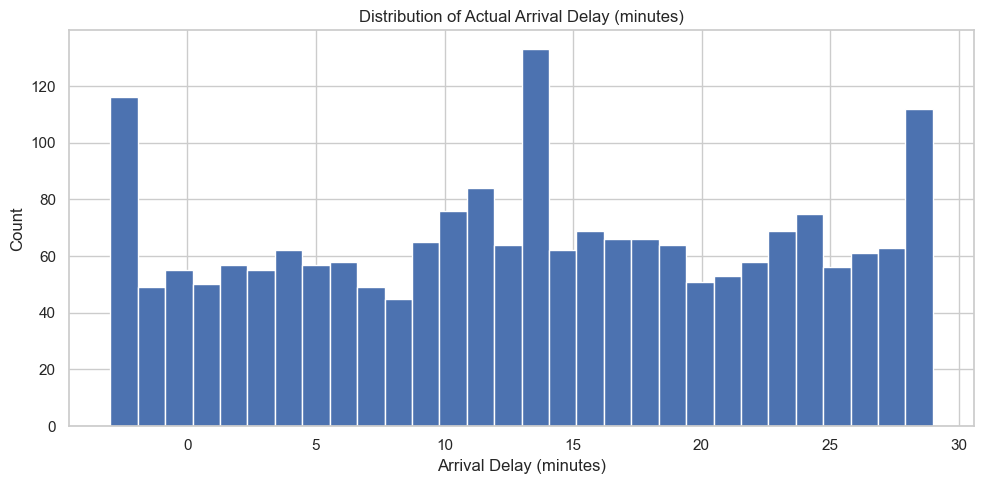

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
df["actual_arrival_delay_min"].hist(bins=30, ax=ax)
ax.set_title("Distribution of Actual Arrival Delay (minutes)")
ax.set_xlabel("Arrival Delay (minutes)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


In [6]:
print("Delayed class counts:")
display(df["delayed"].value_counts().to_frame("count"))

print("Delayed class proportions:")
display(df["delayed"].value_counts(normalize=True).to_frame("proportion"))


Delayed class counts:


,count
delayed,
1,1499
0,501


Delayed class proportions:


,proportion
delayed,
1,0.7495
0,0.2505


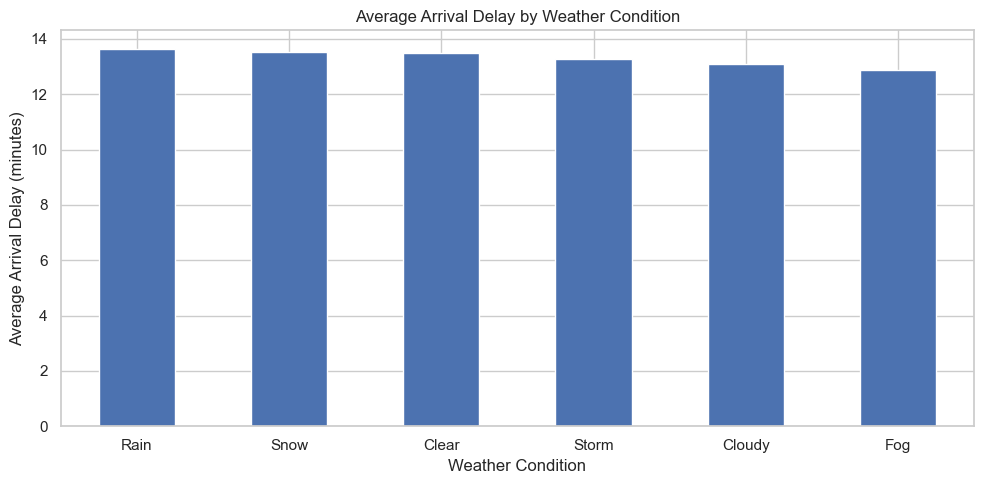

In [7]:
avg_delay_weather = (
    df.groupby("weather_condition")["actual_arrival_delay_min"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
avg_delay_weather.plot(kind="bar")
plt.title("Average Arrival Delay by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Arrival Delay (minutes)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



## Feature Engineering

Raw columns often do not carry the most useful signal in their original form.

To improve model inputs, this project creates engineered features from:
- **dates** → month, day, day of year, weekend
- **scheduled times** → departure hour, arrival hour, trip duration
- **peak periods** → morning peak, evening peak, commute peak
- **events** → whether an event exists, rough event-size bucket
- **weather** → rain, snow, storm, fog, and bad-weather flags
- **numeric thresholds** → high congestion, high wind, heavy precipitation, extreme temperature



In [9]:
df_fe = df.copy()

if "event_type" in df_fe.columns:
    df_fe["event_type"] = df_fe["event_type"].fillna("NoEvent").replace("", "NoEvent")
else:
    df_fe["event_type"] = "NoEvent"

df_fe["date"] = pd.to_datetime(df_fe["date"], errors="coerce")
df_fe["month"] = df_fe["date"].dt.month
df_fe["day"] = df_fe["date"].dt.day
df_fe["day_of_year"] = df_fe["date"].dt.dayofyear
df_fe["is_weekend"] = (df_fe["date"].dt.dayofweek >= 5).astype(int)

dep_split = df_fe["scheduled_departure"].astype(str).str.split(":", expand=True)
arr_split = df_fe["scheduled_arrival"].astype(str).str.split(":", expand=True)

df_fe["scheduled_departure_hour"] = pd.to_numeric(dep_split[0], errors="coerce").fillna(0).astype(int)
df_fe["scheduled_departure_minute"] = pd.to_numeric(dep_split[1], errors="coerce").fillna(0).astype(int)
df_fe["scheduled_arrival_hour"] = pd.to_numeric(arr_split[0], errors="coerce").fillna(0).astype(int)
df_fe["scheduled_arrival_minute"] = pd.to_numeric(arr_split[1], errors="coerce").fillna(0).astype(int)

df_fe["scheduled_departure_minute_of_day"] = (
    df_fe["scheduled_departure_hour"] * 60 + df_fe["scheduled_departure_minute"]
)
df_fe["scheduled_arrival_minute_of_day"] = (
    df_fe["scheduled_arrival_hour"] * 60 + df_fe["scheduled_arrival_minute"]
)
df_fe["scheduled_trip_duration_min"] = (
    df_fe["scheduled_arrival_minute_of_day"] - df_fe["scheduled_departure_minute_of_day"]
).clip(lower=0)

df_fe["is_morning_peak"] = df_fe["scheduled_departure_hour"].between(7, 10).astype(int)
df_fe["is_evening_peak"] = df_fe["scheduled_departure_hour"].between(16, 19).astype(int)
df_fe["is_commute_peak"] = ((df_fe["is_morning_peak"] == 1) | (df_fe["is_evening_peak"] == 1)).astype(int)

df_fe["has_event"] = (df_fe["event_type"].astype(str).str.lower() != "noevent").astype(int)

possible_event_size_cols = ["event_attendance", "event_size", "attendance"]
event_size_col = next((c for c in possible_event_size_cols if c in df_fe.columns), None)

if event_size_col is not None:
    event_size = pd.to_numeric(df_fe[event_size_col], errors="coerce").fillna(0)
else:
    event_size = pd.Series([0] * len(df_fe), index=df_fe.index)

df_fe["event_size_bucket"] = pd.cut(
    event_size,
    bins=[-1, 0, 1000, 10000, float("inf")],
    labels=["NoEvent", "Small", "Medium", "Large"]
).astype(str)

weather_text = df_fe["weather_condition"].astype(str).str.lower()
df_fe["is_rain"] = weather_text.str.contains("rain", na=False).astype(int)
df_fe["is_snow"] = weather_text.str.contains("snow", na=False).astype(int)
df_fe["is_storm"] = weather_text.str.contains("storm|thunder", na=False).astype(int)
df_fe["is_fog"] = weather_text.str.contains("fog|mist|haze", na=False).astype(int)
df_fe["is_bad_weather"] = (
    (df_fe["is_rain"] == 1) | (df_fe["is_snow"] == 1) | (df_fe["is_storm"] == 1) | (df_fe["is_fog"] == 1)
).astype(int)

def get_numeric_col(df, possible_names, default=0):
    for col in possible_names:
        if col in df.columns:
            return pd.to_numeric(df[col], errors="coerce").fillna(default)
    return pd.Series([default] * len(df), index=df.index)

precip = get_numeric_col(df_fe, ["precipitation_mm"])
wind = get_numeric_col(df_fe, ["wind_speed_kmh"])
humidity = get_numeric_col(df_fe, ["humidity_percent", "humidity_%"])
temp = get_numeric_col(df_fe, ["temperature_C", "temperature_c"])
traffic = get_numeric_col(df_fe, ["traffic_congestion_level"])

df_fe["is_heavy_precip"] = (precip >= 5).astype(int)
df_fe["is_high_wind"] = (wind >= 25).astype(int)
df_fe["is_high_humidity"] = (humidity >= 80).astype(int)
df_fe["is_extreme_temp"] = ((temp <= 0) | (temp >= 35)).astype(int)
df_fe["is_high_congestion"] = (traffic >= 7).astype(int)

print("Feature engineered dataframe shape:", df_fe.shape)
df_fe.head()

Feature engineered dataframe shape: (2000, 50)


,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,actual_arrival_delay_min,weather_condition,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed,month,day,day_of_year,is_weekend,scheduled_departure_hour,scheduled_departure_minute,scheduled_arrival_hour,scheduled_arrival_minute,scheduled_departure_minute_of_day,scheduled_arrival_minute_of_day,scheduled_trip_duration_min,is_morning_peak,is_evening_peak,is_commute_peak,has_event,event_size_bucket,is_rain,is_snow,is_storm,is_fog,is_bad_weather,is_heavy_precip,is_high_wind,is_high_humidity,is_extreme_temp,is_high_congestion
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,3,Storm,5.1,52,46,13.0,NoEvent,500,81,0,1,6,Winter,0,1,1,1,1,5,2,5,55,302,355,53,0,0,0,0,NoEvent,0,0,1,0,1,1,1,0,0,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,9,Rain,34.0,64,11,11.4,NoEvent,0,53,0,0,6,Autumn,1,1,1,1,1,5,16,5,55,316,355,39,0,0,0,0,NoEvent,1,0,0,0,1,1,0,0,0,0
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,0,Clear,29.5,35,31,14.1,Sports,0,67,1,0,6,Autumn,0,1,1,1,1,5,33,6,17,333,377,44,0,0,0,1,NoEvent,0,0,0,0,0,1,1,0,0,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,10,Clear,27.4,55,41,6.4,NoEvent,500,84,0,0,6,Winter,1,1,1,1,1,5,49,6,8,349,368,19,0,0,0,0,NoEvent,0,0,0,0,0,1,1,0,0,0
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,14,Snow,0.1,90,30,18.5,NoEvent,500,46,0,0,6,Spring,1,1,1,1,1,6,0,6,35,360,395,35,0,0,0,0,NoEvent,0,1,0,0,1,1,1,1,0,0



## Average Delay by Weather Condition and Event Size

This plot compares average arrival delay across weather conditions and event intensity buckets. It helps identify whether weather and city events appear to interact with transport delays.



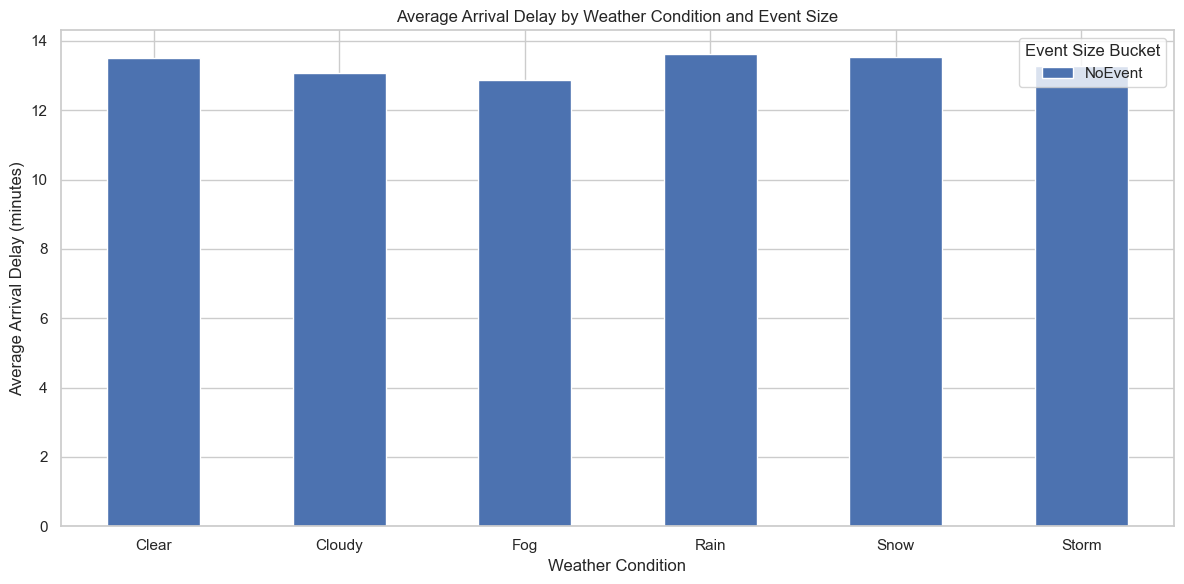

In [10]:
avg_delay = (
    df_fe.groupby(["weather_condition", "event_size_bucket"], dropna=False)["actual_arrival_delay_min"]
    .mean()
    .reset_index()
)

pivot_df = avg_delay.pivot(
    index="weather_condition",
    columns="event_size_bucket",
    values="actual_arrival_delay_min"
)

pivot_df.plot(kind="bar", figsize=(12, 6))
plt.title("Average Arrival Delay by Weather Condition and Event Size")
plt.xlabel("Weather Condition")
plt.ylabel("Average Arrival Delay (minutes)")
plt.xticks(rotation=0)
plt.legend(title="Event Size Bucket")
plt.tight_layout()
plt.show()



## Why Multiple Models Were Used

This project evaluates both regression and classification formulations, so several models are compared rather than relying on a single algorithm.

### Regression models
- **Dummy Regressor** — baseline that predicts the mean target
- **Linear Regression** — simple interpretable baseline
- **Random Forest Regressor** — captures nonlinear relationships
- **Gradient Boosting Regressor** — strong tabular-data model
- **XGBoost Regressor** — advanced boosted-tree model

### Classification models
- **Dummy Classifier** — majority-class baseline
- **Logistic Regression** — interpretable linear classifier
- **Random Forest Classifier** — nonlinear interactions
- **Gradient Boosting Classifier** — structured-data learner
- **XGBoost Classifier** — advanced boosting model

## Secondary Analysis: Regression

The first formulation treats the task as a regression problem where the target is `actual_arrival_delay_min`.

This is a difficult problem because minute-level delays can be noisy and may depend on factors not fully represented in the dataset. The regression results are included as a secondary analysis because they help reveal the limits of the available signal.



In [11]:
with open("regression_metrics.json", "r") as f:
    regression_metrics = json.load(f)

regression_metrics_df = pd.DataFrame(regression_metrics)
regression_metrics_df


,model,mae,rmse,r2
0,GradientBoostingRegressor,8.1355,9.5059,-0.0141
1,DummyRegressor,8.1546,9.4589,-0.0041
2,XGBRegressor,8.1693,9.6697,-0.0494
3,RandomForestRegressor,8.1995,9.6070,-0.0358
4,LinearRegression,8.9846,10.8546,-0.3223



## Interpretation of Regression Results

The regression models performed close to the dummy baseline, and the R² values remained negative across the tested models.

This suggests that exact minute-level delay prediction was difficult with the available features and dataset size. The experiment was still useful because it showed that a more practical problem formulation would likely be classification rather than precise delay-duration prediction.

## Main Analysis: Classification

The main project formulation treats the delay problem as a binary classification task using the `delayed` column.

This is often more practical in real transit settings because an early warning about whether a trip is likely to be delayed may be more useful than an exact minute estimate.



In [12]:
with open("classification_metrics.json", "r") as f:
    classification_metrics = json.load(f)

classification_metrics_df = pd.DataFrame(classification_metrics)
classification_metrics_df


,model,accuracy,precision,recall,f1,roc_auc
0,DummyClassifier,0.7675,0.7675,1.0000,0.8685,0.5000
1,RandomForestClassifier,0.7675,0.7675,1.0000,0.8685,0.4827
2,LogisticRegression,0.7650,0.7669,0.9967,0.8669,0.5069
3,GradientBoostingClassifier,0.7575,0.7665,0.9837,0.8616,0.4841
4,XGBClassifier,0.7400,0.7609,0.9642,0.8506,0.4551



## Understanding Class Balance

Before interpreting the classification results, it is useful to inspect the distribution of the target variable.

If one class dominates the dataset, a simple majority-class baseline can appear deceptively strong on metrics like accuracy and recall. That is why the dummy classifier is included in the comparison.



In [13]:
print("Class counts for 'delayed':")
display(df_fe["delayed"].value_counts().to_frame("count"))

print("Class proportions for 'delayed':")
display(df_fe["delayed"].value_counts(normalize=True).to_frame("proportion"))


Class counts for 'delayed':


,count
delayed,
1,1499
0,501


Class proportions for 'delayed':


,proportion
delayed,
1,0.7495
0,0.2505



## Classification Interpretation

The classification models performed very close to the dummy baseline. This suggests:

1. the `delayed` target is imbalanced  
2. the available features may not provide enough strong signal to separate delayed and non-delayed trips reliably

This is still a useful project outcome because it shows honest evaluation and realistic interpretation.

## Confusion Matrix for the Best Non-Dummy Classifier



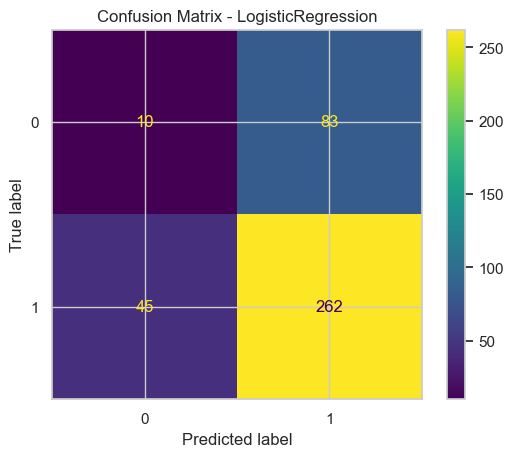

In [15]:
exclude_for_classification = ["actual_arrival_delay_min", "actual_departure_delay_min", "delayed", "date"]
classification_df = df_fe.drop(columns=[c for c in exclude_for_classification if c in df_fe.columns]).copy()
y_class = df_fe["delayed"].copy()

split_idx = int(len(classification_df) * 0.8)
X_train_cls = classification_df.iloc[:split_idx].copy()
X_test_cls = classification_df.iloc[split_idx:].copy()
y_train_cls = y_class.iloc[:split_idx].copy()
y_test_cls = y_class.iloc[split_idx:].copy()

categorical_cols = X_train_cls.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train_cls.select_dtypes(include=["number", "bool"]).columns.tolist()

preprocessor_cls = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_cols),
    ]
)

clf_candidates = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForestClassifier": RandomForestClassifier(n_estimators=300, random_state=42),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=42),
}

best_non_dummy_name = classification_metrics_df[
    classification_metrics_df["model"] != "DummyClassifier"
].sort_values("roc_auc", ascending=False).iloc[0]["model"]

best_non_dummy_pipeline = Pipeline([
    ("preprocessor", preprocessor_cls),
    ("model", clf_candidates[best_non_dummy_name])
])

best_non_dummy_pipeline.fit(X_train_cls, y_train_cls)
y_pred_cls = best_non_dummy_pipeline.predict(X_test_cls)

cm = confusion_matrix(y_test_cls, y_pred_cls)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Confusion Matrix - {best_non_dummy_name}")
plt.show()


## Feature Importance for Interpretation



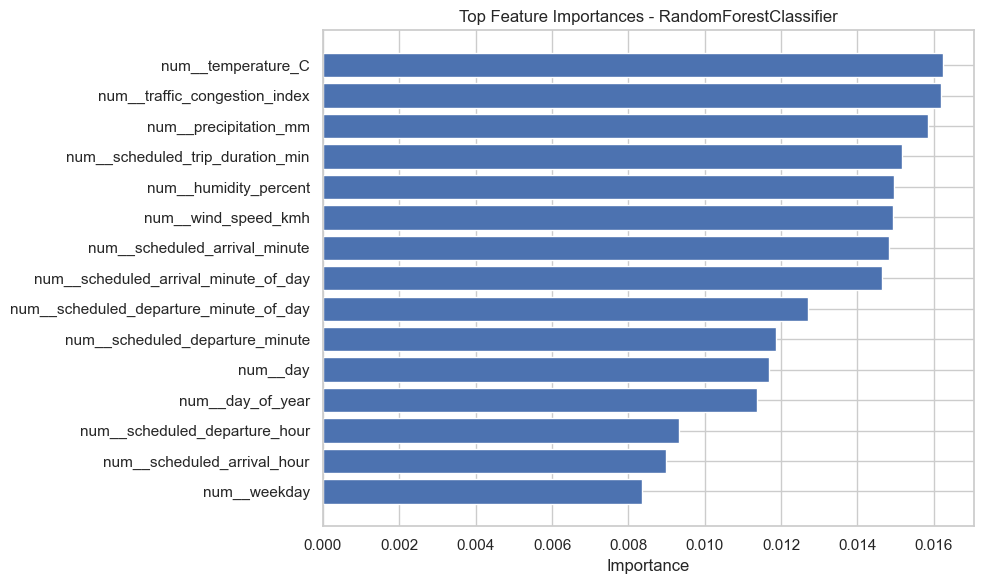

,feature,importance
0,num__temperature_C,0.016241
5,num__traffic_congestion_index,0.016185
3,num__precipitation_mm,0.015852
19,num__scheduled_trip_duration_min,0.015158
1,num__humidity_percent,0.014948
2,num__wind_speed_kmh,0.014938
16,num__scheduled_arrival_minute,0.014819
18,num__scheduled_arrival_minute_of_day,0.014651
17,num__scheduled_departure_minute_of_day,0.012693
14,num__scheduled_departure_minute,0.011869


In [16]:
tree_pipeline = Pipeline([
    ("preprocessor", preprocessor_cls),
    ("model", RandomForestClassifier(n_estimators=300, random_state=42))
])

tree_pipeline.fit(X_train_cls, y_train_cls)

feature_names = tree_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = tree_pipeline.named_steps["model"].feature_importances_

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(fi_df["feature"][::-1], fi_df["importance"][::-1])
plt.title("Top Feature Importances - RandomForestClassifier")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

fi_df



## Inference Demonstration

The saved model artifacts were successfully loaded and used through `predict.py`.

Observed example outputs:
- classification prediction: `delayed = 1`
- classification probabilities: `[0.0, 1.0]`
- regression prediction: `13.13` minutes

This confirms that the end-to-end training and inference pipeline is functional.



In [17]:
print("Classification inference example:")
print("Predicted delayed: 1")
print("Class probabilities: [0. 1.]")
print()
print("Regression inference example:")
print("Predicted arrival delay (minutes): 13.13")


Classification inference example:
Predicted delayed: 1
Class probabilities: [0. 1.]

Regression inference example:
Predicted arrival delay (minutes): 13.13



## Project Difficulties and Limitations

This project produced a working machine learning pipeline, but the predictive results also revealed important limitations.

### Regression difficulty
Predicting the exact delay in minutes turned out to be difficult. The regression models stayed close to the dummy baseline, and the negative R² values suggested limited predictive structure for the minute-level target.

### Classification difficulty
The classification models also performed close to the dummy majority baseline. This likely reflects:
- class imbalance
- limited feature signal
- unobserved operational factors not included in the dataset

### Why this is still a strong project
Even when performance is limited, this project still demonstrates:
- structured data cleaning
- leakage-aware modeling
- feature engineering
- baseline comparison
- honest model interpretation
- saved artifacts and inference
- end-to-end reproducibility

## Final Conclusion

This project explored two machine learning formulations for public transport delay prediction using schedule, route, weather, traffic, and city-event features.

- The **regression analysis** attempted to predict exact arrival delay in minutes, but the models remained close to a dummy mean baseline.
- The **classification analysis** attempted to predict whether a trip would be delayed, but those models also performed close to a majority-class baseline.

These results suggest that the dataset contains limited predictive signal for both precise delay-duration estimation and delayed/not-delayed classification, at least with the current features and sample size.

Even though predictive performance was limited, the project successfully demonstrates a complete machine learning workflow:
- data inspection and cleaning
- leakage-aware preprocessing
- feature engineering
- exploratory analysis
- regression and classification modeling
- baseline comparison
- model evaluation
- artifact saving with `joblib`
- end-to-end inference with a prediction script
